# NLP04: BERT Pretraining 실습

이번 노트북에서는 한국어 위키 코퍼스를 이용해 BERT pretraining용 데이터를 만들고, mini BERT 모델을 직접 구현해 학습합니다.

진행 순서는 다음과 같습니다.

1. 환경 설정 및 데이터 준비
2. SentencePiece tokenizer 준비
3. MLM 데이터 생성
4. NSP 데이터 생성
5. pretrain 데이터 저장 및 로딩
6. mini BERT 모델 구현
7. pretrain 학습 및 결과 시각화


## 루브릭 체크포인트

- MLM, NSP task의 특징이 반영된 pretraining 데이터셋을 생성한다.
- 학습 과정에서 MLM loss와 NSP loss가 안정적으로 감소하는지 확인한다.
- 학습된 모델과 학습 과정의 시각화 결과를 제출한다.


## 1. 환경 설정

먼저 필요한 라이브러리를 불러오고, 재현 가능한 실험을 위해 random seed를 고정합니다.
데이터와 모델 파일은 각각 `data`, `models`, `work` 폴더에 저장합니다.


In [31]:
# 필요한 패키지가 없을 경우 아래 줄을 한 번 실행합니다.
%pip install -q sentencepiece tqdm torchinfo


Note: you may need to restart the kernel to use updated packages.


In [32]:
from __future__ import absolute_import, division, print_function, unicode_literals

import os
import re
import math
import json
import time
import random
import zipfile
import shutil
import collections
import urllib.request
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.amp import autocast, GradScaler

import sentencepiece as spm
from tqdm.auto import tqdm

random_seed = 1234
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(random_seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch version:", torch.__version__)
print("device:", device)


torch version: 2.11.0+cu128
device: cuda


In [33]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
MODEL_DIR = BASE_DIR / "models"
WORK_DIR = BASE_DIR / "work"

for path in (DATA_DIR, MODEL_DIR, WORK_DIR):
    path.mkdir(parents=True, exist_ok=True)

# 빠른 실습을 위해 기본값은 일부 데이터만 사용합니다.
# 전체 데이터로 학습하려면 FAST_RUN을 "0"으로 바꾸면 됩니다.
os.environ.setdefault("BERT_PRETRAIN_FAST_RUN", "1")
os.environ.setdefault("BERT_PRETRAIN_MAX_LINES", "20000")
os.environ["BERT_PRETRAIN_COUNT"] = "2048"
os.environ["BERT_PRETRAIN_EPOCHS"] = "8"
os.environ["BERT_PRETRAIN_BATCH_SIZE"] = "16"
os.environ.setdefault("BERT_PRETRAIN_SP_VOCAB_SIZE", "8000")

print("BASE_DIR:", BASE_DIR)
print("DATA_DIR:", DATA_DIR)
print("MODEL_DIR:", MODEL_DIR)
print("WORK_DIR:", WORK_DIR)


BASE_DIR: c:\Users\Administrator\Desktop\codex-workspace\AIFFEL_quest_eng\NLP\NLP04
DATA_DIR: c:\Users\Administrator\Desktop\codex-workspace\AIFFEL_quest_eng\NLP\NLP04\data
MODEL_DIR: c:\Users\Administrator\Desktop\codex-workspace\AIFFEL_quest_eng\NLP\NLP04\models
WORK_DIR: c:\Users\Administrator\Desktop\codex-workspace\AIFFEL_quest_eng\NLP\NLP04\work


## BERT, MLM, NSP 먼저 이해하기

BERT는 문장의 앞뒤 문맥을 함께 보면서 단어와 문장의 의미를 숫자 벡터로 표현하는 Transformer encoder 기반 언어 모델입니다.

- **BERT**: 문장 전체의 양방향 문맥을 보고 의미를 이해하는 모델
- **MLM**: 문장 일부를 `[MASK]`로 가리고 원래 토큰을 맞히는 학습 task
- **NSP**: 두 문장이 실제로 이어지는 문장인지 맞히는 학습 task

이번 실습에서는 한국어 코퍼스를 토큰화한 뒤, MLM과 NSP 문제를 직접 만들어 mini BERT가 두 task를 동시에 학습하도록 합니다.


### MLM 예시

원문이 `나는 오늘 학교에 갔다`라면, MLM 입력은 다음처럼 만들 수 있습니다.

```text
[CLS] 나는 오늘 [MASK]에 갔다 [SEP]
```

모델은 `[MASK]` 위치에 원래 어떤 토큰이 있었는지 맞힙니다. 따라서 코드에서는 `mask_idx`와 `mask_label`을 함께 저장합니다.


### NSP 예시

NSP는 두 문장이 자연스럽게 이어지는지 판단합니다.

```text
[CLS] 문장 A [SEP] 문장 B [SEP]
```

문장 A 영역은 segment `0`, 문장 B 영역은 segment `1`로 표시합니다. 두 문장이 이어지면 `is_next=1`, 이어지지 않으면 `is_next=0`으로 라벨을 만듭니다.


## 2. 데이터 준비와 SentencePiece 토크나이저

BERT는 문장을 바로 글자 단위로 보지 않고, tokenizer가 나눈 token 단위로 입력을 받습니다. 여기서는 한국어 위키 코퍼스로 SentencePiece BPE tokenizer를 만들고 사용합니다.

실습 시간을 줄이기 위해 기본 설정에서는 전체 코퍼스 중 일부만 사용합니다.


In [34]:
CORPUS_URL = "https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip"
ZIP_PATH = DATA_DIR / "kowiki.txt.zip"
FULL_CORPUS_PATH = DATA_DIR / "kowiki.txt"
SMALL_CORPUS_PATH = DATA_DIR / "kowiki_small.txt"

sample_text = """
인공지능은 컴퓨터가 사람처럼 학습하고 추론하도록 만드는 기술이다.
자연어 처리는 사람이 사용하는 언어를 컴퓨터가 이해하도록 만드는 분야이다.
BERT는 Transformer encoder 구조를 기반으로 만들어진 언어 모델이다.
Masked Language Modeling은 일부 토큰을 가리고 원래 토큰을 맞히는 학습 방식이다.
Next Sentence Prediction은 두 문장이 이어지는지 판단하는 학습 방식이다.

딥러닝 모델은 많은 데이터를 사용하여 패턴을 학습한다.
토크나이저는 문장을 작은 단위의 토큰으로 나누는 역할을 한다.
SentencePiece는 subword 기반 토크나이저를 만들 때 자주 사용된다.
""".strip()

if not FULL_CORPUS_PATH.exists():
    try:
        if not ZIP_PATH.exists():
            print("Downloading kowiki.txt.zip...")
            urllib.request.urlretrieve(CORPUS_URL, ZIP_PATH)

        print("Extracting kowiki.txt.zip...")
        with zipfile.ZipFile(ZIP_PATH, "r") as zf:
            zf.extractall(DATA_DIR)
    except Exception as e:
        print("kowiki.txt 다운로드에 실패하여 샘플 코퍼스를 사용합니다.")
        print("reason:", e)
        FULL_CORPUS_PATH.write_text((sample_text + "\n\n") * 2000, encoding="utf-8")

if not FULL_CORPUS_PATH.exists():
    found = list(DATA_DIR.rglob("kowiki.txt"))
    if found:
        shutil.copy(found[0], FULL_CORPUS_PATH)

if not FULL_CORPUS_PATH.exists():
    FULL_CORPUS_PATH.write_text((sample_text + "\n\n") * 2000, encoding="utf-8")

fast_run = os.environ.get("BERT_PRETRAIN_FAST_RUN", "1") == "1"
max_lines = int(os.environ.get("BERT_PRETRAIN_MAX_LINES", "20000"))

if fast_run:
    with FULL_CORPUS_PATH.open("r", encoding="utf-8") as src, SMALL_CORPUS_PATH.open("w", encoding="utf-8") as dst:
        for i, line in enumerate(src):
            if i >= max_lines:
                break
            dst.write(line)
    corpus_file = SMALL_CORPUS_PATH
else:
    corpus_file = FULL_CORPUS_PATH

os.environ["BERT_PRETRAIN_CORPUS_FILE"] = str(corpus_file)
print("corpus_file:", corpus_file)
print("corpus_size_mb:", round(corpus_file.stat().st_size / 1024 / 1024, 2))


corpus_file: c:\Users\Administrator\Desktop\codex-workspace\AIFFEL_quest_eng\NLP\NLP04\data\kowiki_small.txt
corpus_size_mb: 6.51


In [35]:
sp_vocab_size = int(os.environ.get("BERT_PRETRAIN_SP_VOCAB_SIZE", "8000"))
model_prefix = DATA_DIR / "ko_32000"
model_path = DATA_DIR / "ko_32000.model"
vocab_path = DATA_DIR / "ko_32000.vocab"

if not model_path.exists():
    spm.SentencePieceTrainer.train(
        f"--input={corpus_file} "
        f"--model_prefix={model_prefix} "
        f"--vocab_size={sp_vocab_size + 7} "
        "--model_type=bpe "
        "--max_sentence_length=999999 "
        "--pad_id=0 --pad_piece=[PAD] "
        "--unk_id=1 --unk_piece=[UNK] "
        "--bos_id=2 --bos_piece=[BOS] "
        "--eos_id=3 --eos_piece=[EOS] "
        "--user_defined_symbols=[SEP],[CLS],[MASK] "
        "--hard_vocab_limit=false"
    )

print("model exists:", model_path.exists(), model_path)
print("vocab exists:", vocab_path.exists(), vocab_path)


model exists: True c:\Users\Administrator\Desktop\codex-workspace\AIFFEL_quest_eng\NLP\NLP04\data\ko_32000.model
vocab exists: True c:\Users\Administrator\Desktop\codex-workspace\AIFFEL_quest_eng\NLP\NLP04\data\ko_32000.vocab


In [36]:
vocab = spm.SentencePieceProcessor()
vocab.load(str(model_path))
REAL_VOCAB_SIZE = vocab.get_piece_size()

special_tokens = [vocab.id_to_piece(i) for i in range(7)]
vocab_list = []
for token_id in range(7, REAL_VOCAB_SIZE):
    if not vocab.is_unknown(token_id):
        vocab_list.append(vocab.id_to_piece(token_id))

print("REAL_VOCAB_SIZE:", REAL_VOCAB_SIZE)
print("special_tokens:", special_tokens)
print("vocab_list size:", len(vocab_list))
print("vocab sample:", vocab_list[:30])

test_sentence = "BERT는 문장의 앞뒤 문맥을 함께 보는 언어 모델이다."
test_pieces = vocab.encode_as_pieces(test_sentence)
test_ids = vocab.encode_as_ids(test_sentence)
print("sentence:", test_sentence)
print("pieces:", test_pieces)
print("ids:", test_ids)


REAL_VOCAB_SIZE: 8007
special_tokens: ['[PAD]', '[UNK]', '[BOS]', '[EOS]', '[SEP]', '[CLS]', '[MASK]']
vocab_list size: 8000
vocab sample: ['▁이', '▁1', '으로', '▁있', '에서', '▁그', '▁대', '▁사', '▁수', '▁2', '었다', '▁기', '▁가', '▁한', '▁전', '▁정', '▁지', '▁있다', '하는', '▁19', '하였', '▁아', '▁다', '▁시', '했다', '▁것', '▁중', '▁일', '이다', '▁자']
sentence: BERT는 문장의 앞뒤 문맥을 함께 보는 언어 모델이다.
pieces: ['▁B', 'E', 'R', 'T', '는', '▁문', '장의', '▁앞', '뒤', '▁문', '맥', '을', '▁함께', '▁보는', '▁언어', '▁모델', '이다', '.']
ids: [688, 5766, 5753, 5686, 5390, 80, 1787, 774, 5768, 80, 5810, 5394, 328, 3186, 445, 1325, 35, 5388]


## 3. MLM 데이터 생성

MLM은 입력 토큰 중 일부를 가리고, 가리기 전 원래 토큰을 맞히도록 학습하는 task입니다.
BERT 논문 방식처럼 선택된 토큰은 80% 확률로 `[MASK]`, 10% 확률로 원래 토큰 유지, 10% 확률로 랜덤 토큰으로 바꿉니다.

이 단계에서는 `tokens`, `mask_idx`, `mask_label`을 만듭니다.

- `tokens`: 모델에 입력할 토큰 목록
- `mask_idx`: MLM 대상으로 선택된 토큰 위치
- `mask_label`: 해당 위치의 원래 정답 토큰


In [37]:
sentence_a = "추적추적 비가 내리는 날이었다."
sentence_b = "그날은 손님이 많아 가게가 붐비었다."

tokens_a = vocab.encode_as_pieces(sentence_a)
tokens_b = vocab.encode_as_pieces(sentence_b)
tokens_org = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]

print("sentence_a:", sentence_a)
print("sentence_b:", sentence_b)
print("tokens_org:")
print(tokens_org)
print("token_count:", len(tokens_org))


sentence_a: 추적추적 비가 내리는 날이었다.
sentence_b: 그날은 손님이 많아 가게가 붐비었다.
tokens_org:
['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었다', '.', '[SEP]', '▁그', '날', '은', '▁손', '님', '이', '▁많아', '▁가', '게', '가', '▁', '붐', '비', '었다', '.', '[SEP]']
token_count: 29


In [38]:
def create_pretrain_mask(tokens, mask_cnt, vocab_list, rng=None):
    """Create masked tokens, mask indices, and original mask labels for MLM."""
    rng = rng or random
    tokens = list(tokens)

    valid_token_indices = [
        i for i, token in enumerate(tokens)
        if token not in ("[CLS]", "[SEP]")
    ]
    if not valid_token_indices or mask_cnt <= 0:
        return tokens, [], []

    mask_cnt = min(mask_cnt, len(valid_token_indices))

    # Group subword pieces by word. SentencePiece uses \u2581 as a word-start marker.
    cand_idx = []
    for i in valid_token_indices:
        token = tokens[i]
        if cand_idx and not token.startswith("\u2581"):
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])

    rng.shuffle(cand_idx)

    mask_lms = []
    covered = set()
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:
            break
        if any(index in covered for index in index_set):
            continue
        if len(mask_lms) + len(index_set) > mask_cnt:
            continue

        for index in index_set:
            original_token = tokens[index]
            dice = rng.random()
            if dice < 0.8:
                masked_token = "[MASK]"
            elif dice < 0.9:
                masked_token = original_token
            else:
                masked_token = rng.choice(vocab_list)

            mask_lms.append({"index": index, "label": original_token})
            covered.add(index)
            tokens[index] = masked_token

    if not mask_lms:
        for index in valid_token_indices[:mask_cnt]:
            original_token = tokens[index]
            tokens[index] = "[MASK]"
            mask_lms.append({"index": index, "label": original_token})

    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_idx = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]

    return tokens, mask_idx, mask_label


In [39]:
mask_prob = 0.15
mask_cnt = max(1, int(round((len(tokens_org) - 3) * mask_prob)))

masked_tokens, mask_idx, mask_label = create_pretrain_mask(
    tokens_org,
    mask_cnt,
    vocab_list,
    rng=random.Random(random_seed)
)

print("mask_cnt:", mask_cnt)
print("masked_tokens:")
print(masked_tokens)
print("mask_idx:", mask_idx)
print("mask_label:", mask_label)


mask_cnt: 4
masked_tokens:
['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '[MASK]', '[MASK]', '[MASK]', '[SEP]', '▁그', '날', '은', '▁손', '님', '이', '▁없', '▁가', '게', '가', '▁', '붐', '비', '었다', '.', '[SEP]']
mask_idx: [9, 10, 11, 19]
mask_label: ['▁날', '이었다', '.', '▁많아']


`[MASK]`나 랜덤 토큰으로 바꾸면 입력에서 원래 토큰이 사라집니다.
그래서 나중에 채점할 수 있도록 원래 토큰을 `mask_label`에 정답지로 보관합니다.
모델은 `masked_tokens`만 입력으로 보고, `mask_label`은 loss를 계산할 때만 사용됩니다.


## 4. NSP 데이터 생성

NSP는 두 문장이 실제로 이어지는 문장인지 맞히는 task입니다.
BERT 입력은 `[CLS] 문장 A [SEP] 문장 B [SEP]` 형태로 만들고, 문장 A와 문장 B를 구분하기 위해 segment 값을 함께 만듭니다.

- `segment=0`: 첫 번째 문장 영역
- `segment=1`: 두 번째 문장 영역
- `is_next=1`: 두 문장이 이어짐
- `is_next=0`: 두 문장이 이어지지 않음


In [40]:
n_seq = 64
max_seq = n_seq - 3  # exclude [CLS], [SEP], [SEP]

doc_text = """
추적추적 비가 내리는 날이었다.
그날은 손님이 많아 가게가 붐비었다.
나는 따뜻한 차를 한 잔 마셨다.
창밖의 빗소리가 조용히 이어졌다.

BERT는 문장의 앞뒤 문맥을 함께 본다.
MLM은 가려진 토큰을 맞히는 방식이다.
NSP는 두 문장의 연결 관계를 학습한다.
이 두 task를 통해 언어 표현을 학습할 수 있다.
""".strip()

doc = []
for line in doc_text.splitlines():
    line = line.strip()
    if line:
        doc.append(vocab.encode_as_pieces(line))

print("line_count:", len(doc))
for i, line_tokens in enumerate(doc[:4], 1):
    print(i, line_tokens)


line_count: 8
1 ['▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었다', '.']
2 ['▁그', '날', '은', '▁손', '님', '이', '▁많아', '▁가', '게', '가', '▁', '붐', '비', '었다', '.']
3 ['▁나는', '▁따', '뜻', '한', '▁차', '를', '▁한', '▁잔', '▁마', '셨', '다', '.']
4 ['▁창', '밖', '의', '▁', '빗', '소', '리가', '▁조', '용', '히', '▁이어', '졌다', '.']


In [41]:
def trim_tokens(tokens_a, tokens_b, max_seq):
    """Trim two token lists so their total length fits max_seq."""
    while len(tokens_a) + len(tokens_b) > max_seq:
        if len(tokens_a) > len(tokens_b):
            tokens_a.pop()
        else:
            tokens_b.pop()


In [42]:
def create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list, rng=None):
    """Create BERT pretraining instances for MLM and NSP from one document."""
    rng = rng or random
    max_seq = n_seq - 3

    instances = []
    current_chunk = []
    current_length = 0

    for i, line_tokens in enumerate(doc):
        current_chunk.append(line_tokens)
        current_length += len(line_tokens)

        if len(current_chunk) > 1 and (i == len(doc) - 1 or current_length >= max_seq):
            a_end = rng.randrange(1, len(current_chunk))

            tokens_a = []
            for j in range(a_end):
                tokens_a.extend(current_chunk[j])

            tokens_b = []
            for j in range(a_end, len(current_chunk)):
                tokens_b.extend(current_chunk[j])

            # Create a NotNext example by swapping sentence order with 50% probability.
            if rng.random() < 0.5:
                is_next = 0
                tokens_a, tokens_b = tokens_b, tokens_a
            else:
                is_next = 1

            trim_tokens(tokens_a, tokens_b, max_seq)
            if not tokens_a or not tokens_b:
                current_chunk = []
                current_length = 0
                continue

            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)

            mask_cnt = max(1, int(round((len(tokens) - 3) * mask_prob)))
            tokens, mask_idx, mask_label = create_pretrain_mask(tokens, mask_cnt, vocab_list, rng=rng)

            instances.append({
                "tokens": tokens,
                "segment": segment,
                "is_next": is_next,
                "mask_idx": mask_idx,
                "mask_label": mask_label
            })

            current_chunk = []
            current_length = 0

    return instances


In [43]:
instances = create_pretrain_instances(
    vocab=vocab,
    doc=doc,
    n_seq=n_seq,
    mask_prob=0.15,
    vocab_list=vocab_list,
    rng=random.Random(random_seed)
)

print("instances:", len(instances))
for key, value in instances[0].items():
    print(f"{key}: {value}")
print("token_len:", len(instances[0]["tokens"]))
print("segment_len:", len(instances[0]["segment"]))


instances: 2
tokens: ['[CLS]', '▁B', 'E', 'R', 'T', '는', '▁문', '장의', '▁앞', '뒤', '▁문', '맥', '을', '[MASK]', '▁본', '다', '.', '[SEP]', '▁추', '적', '추', '적', '▁비', '가', '[MASK]', '[MASK]', '▁날', '이었다', '.', '▁그', '날', '은', '▁손', '님', '이', '▁많아', '▁가', '게', '가', '▁', '붐', '비', '었다', '.', '▁나는', '▁따', '뜻', '한', '[MASK]', '[MASK]', '▁한', '▁잔', '▁마', '셨', '다', '.', '[MASK]', '▁번', '[MASK]', '▁', '빗', '소', '리가', '[SEP]']
segment: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
is_next: 0
mask_idx: [13, 24, 25, 48, 49, 51, 56, 57, 58]
mask_label: ['▁함께', '▁내', '리는', '▁차', '를', '▁잔', '▁창', '밖', '의']
token_len: 64
segment_len: 64


NSP 단계까지 끝나면 하나의 instance 안에 MLM 정보와 NSP 정보가 함께 들어갑니다.
`tokens`, `mask_idx`, `mask_label`은 MLM 학습에 쓰이고, `segment`, `is_next`는 NSP 학습에 쓰입니다.


## 5. Pretrain 데이터 파일 생성과 로딩

이제 예시 문장이 아니라 코퍼스 파일에 들어 있는 여러 문장에 같은 로직을 적용합니다.
먼저 MLM/NSP instance를 JSONL 파일로 저장하고, 그다음 모델 학습에 사용할 숫자 배열로 변환합니다.


In [44]:
pretrain_json_path = WORK_DIR / "bert_pre_train.jsonl"
n_seq = 64
mask_prob = 0.15

print("corpus_file:", corpus_file)
print("pretrain_json_path:", pretrain_json_path)
print("n_seq:", n_seq)


corpus_file: c:\Users\Administrator\Desktop\codex-workspace\AIFFEL_quest_eng\NLP\NLP04\data\kowiki_small.txt
pretrain_json_path: c:\Users\Administrator\Desktop\codex-workspace\AIFFEL_quest_eng\NLP\NLP04\work\bert_pre_train.jsonl
n_seq: 64


In [45]:
def make_pretrain_data(vocab, in_file, out_file, n_seq, mask_prob=0.15, max_docs=None, rng=None):
    """Read a corpus file and save BERT pretraining instances as JSONL."""
    rng = rng or random
    out_file = Path(out_file)
    out_file.parent.mkdir(parents=True, exist_ok=True)

    doc_count = 0
    instance_count = 0
    doc = []

    def flush_doc(out_f, doc):
        nonlocal instance_count
        if len(doc) < 2:
            return
        instances = create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list, rng=rng)
        for instance in instances:
            out_f.write(json.dumps(instance, ensure_ascii=False) + "\n")
        instance_count += len(instances)

    with open(in_file, "r", encoding="utf-8") as in_f, open(out_file, "w", encoding="utf-8") as out_f:
        for line in tqdm(in_f, desc="make pretrain data"):
            line = line.strip()

            if line == "":
                if doc:
                    flush_doc(out_f, doc)
                    doc_count += 1
                    doc = []
                    if max_docs is not None and doc_count >= max_docs:
                        break
            else:
                pieces = vocab.encode_as_pieces(line)
                if pieces:
                    doc.append(pieces)

        if doc and (max_docs is None or doc_count < max_docs):
            flush_doc(out_f, doc)
            doc_count += 1

    return doc_count, instance_count


In [46]:
fast_run = os.environ.get("BERT_PRETRAIN_FAST_RUN", "1") == "1"
max_docs = 300 if fast_run else None

doc_count, instance_count = make_pretrain_data(
    vocab=vocab,
    in_file=corpus_file,
    out_file=pretrain_json_path,
    n_seq=n_seq,
    mask_prob=mask_prob,
    max_docs=max_docs,
    rng=random.Random(random_seed)
)

print("doc_count:", doc_count)
print("instance_count:", instance_count)
print("file_size_mb:", round(pretrain_json_path.stat().st_size / 1024 / 1024, 2))


make pretrain data: 7078it [00:00, 8516.09it/s]

doc_count: 300
instance_count: 2671
file_size_mb: 2.56


In [47]:
with open(pretrain_json_path, "r", encoding="utf-8") as f:
    first_instance = json.loads(next(f))

for key, value in first_instance.items():
    print(f"{key}: {value}")


tokens: ['[CLS]', '▁지', '미', '▁카', '터', '는', '▁조지', '아', '주', '▁섬', '터', '[MASK]', '[MASK]', '[MASK]', '▁플', '레', '인', '스', '[MASK]', '▁번', '▁태어났다', '.', '[MASK]', '[MASK]', '▁공', '과', '대학교', '를', '▁졸업', '하였다', '.', '▁그', '[SEP]', '▁지', '미', '▁카', '터', '▁제임스', '▁얼', '▁"', '지', '미', '"', '▁카', '터', '▁주', '니', '어', '(,', '▁1924', '년', '▁10', '[MASK]', '▁1', '일', '▁~', '▁)', '는', '▁민주당', '▁출신', '▁미국', '▁3', '9', '[SEP]']
segment: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
is_next: 0
mask_idx: [11, 12, 13, 18, 19, 22, 23, 51, 52]
mask_label: ['▁카', '운', '티', '▁마을', '에서', '▁조지', '아', '▁10', '월']


In [48]:
def load_pre_train_data(vocab, filename, n_seq, count=None):
    """Load JSONL pretraining instances and convert them to fixed-size numpy arrays."""
    token_pad_id = vocab.piece_to_id("[PAD]")
    label_pad_id = 0

    enc_tokens = []
    segments = []
    labels_nsp = []
    labels_mlm = []

    with open(filename, "r", encoding="utf-8") as f:
        for i, line in enumerate(tqdm(f, desc="load pretrain data")):
            if count is not None and i >= count:
                break

            instance = json.loads(line)
            token_ids = vocab.piece_to_id(instance["tokens"])[:n_seq]
            segment_ids = instance["segment"][:n_seq]
            mlm_label_ids = [label_pad_id] * n_seq

            for mask_pos, mask_token in zip(instance["mask_idx"], instance["mask_label"]):
                if mask_pos < n_seq:
                    mlm_label_ids[mask_pos] = vocab.piece_to_id(mask_token)

            pad_len = n_seq - len(token_ids)
            if pad_len > 0:
                token_ids += [token_pad_id] * pad_len
                segment_ids += [0] * pad_len

            enc_tokens.append(token_ids)
            segments.append(segment_ids)
            labels_nsp.append(instance["is_next"])
            labels_mlm.append(mlm_label_ids)

    pre_train_inputs = [
        np.asarray(enc_tokens, dtype=np.int64),
        np.asarray(segments, dtype=np.int64)
    ]
    pre_train_labels = [
        np.asarray(labels_nsp, dtype=np.int64),
        np.asarray(labels_mlm, dtype=np.int64)
    ]
    return pre_train_inputs, pre_train_labels


In [49]:
train_count = int(os.environ.get("BERT_PRETRAIN_COUNT", "4096"))
pre_train_inputs, pre_train_labels = load_pre_train_data(
    vocab=vocab,
    filename=pretrain_json_path,
    n_seq=n_seq,
    count=train_count
)

print("enc_tokens shape:", pre_train_inputs[0].shape)
print("segments shape:", pre_train_inputs[1].shape)
print("labels_nsp shape:", pre_train_labels[0].shape)
print("labels_mlm shape:", pre_train_labels[1].shape)
print("first token ids:", pre_train_inputs[0][0][:20])
print("first mlm labels:", pre_train_labels[1][0][:20])


load pretrain data: 2048it [00:00, 14852.23it/s]

enc_tokens shape: (2048, 64)
segments shape: (2048, 64)
labels_nsp shape: (2048,)
labels_mlm shape: (2048, 64)
first token ids: [   5   23 5488  213 5504 5390 2200 5424 5436 1028 5504    6    6    6
  492 5559 5406 5413    6  568]
first mlm labels: [   0    0    0    0    0    0    0    0    0    0    0  213 5536 5680
    0    0    0    0 3811   11]


이 단계까지 오면 학습용 입력과 라벨이 숫자 배열로 준비됩니다.
다음 단계에서는 이 배열을 mini BERT 모델에 넣어 MLM loss와 NSP loss를 계산합니다.


## 6. mini BERT 모델 구현

이제 학습용 입력 배열을 받아 MLM과 NSP를 동시에 예측하는 mini BERT 모델을 만듭니다.

BERT 입력은 세 가지 embedding을 더해서 만듭니다.

- token embedding: token id 자체의 의미
- position embedding: token 위치 정보
- segment embedding: 문장 A/B 구분 정보

그다음 Transformer encoder를 통과시킨 후, MLM head는 가려진 토큰을 예측하고 NSP head는 `[CLS]` 위치로 두 문장의 연결 여부를 예측합니다.


In [50]:
class BertConfig:
    def __init__(
        self,
        vocab_size,
        max_position_embeddings=64,
        type_vocab_size=2,
        hidden_size=96,
        num_hidden_layers=2,
        num_attention_heads=4,
        intermediate_size=384,
        hidden_dropout_prob=0.1
    ):
        self.vocab_size = vocab_size
        self.max_position_embeddings = max_position_embeddings
        self.type_vocab_size = type_vocab_size
        self.hidden_size = hidden_size
        self.num_hidden_layers = num_hidden_layers
        self.num_attention_heads = num_attention_heads
        self.intermediate_size = intermediate_size
        self.hidden_dropout_prob = hidden_dropout_prob


config = BertConfig(
    vocab_size=REAL_VOCAB_SIZE,
    max_position_embeddings=n_seq
)

print("vocab_size:", config.vocab_size)
print("hidden_size:", config.hidden_size)
print("num_hidden_layers:", config.num_hidden_layers)
print("num_attention_heads:", config.num_attention_heads)


vocab_size: 8007
hidden_size: 96
num_hidden_layers: 2
num_attention_heads: 4


In [51]:
class BertEmbeddings(nn.Module):
    def __init__(self, config, pad_token_id=0):
        super().__init__()
        self.token_embeddings = nn.Embedding(
            config.vocab_size,
            config.hidden_size,
            padding_idx=pad_token_id
        )
        self.position_embeddings = nn.Embedding(
            config.max_position_embeddings,
            config.hidden_size
        )
        self.segment_embeddings = nn.Embedding(
            config.type_vocab_size,
            config.hidden_size
        )
        self.layer_norm = nn.LayerNorm(config.hidden_size)
        self.dropout = nn.Dropout(config.hidden_dropout_prob)

    def forward(self, input_ids, segment_ids):
        batch_size, seq_len = input_ids.shape
        position_ids = torch.arange(seq_len, device=input_ids.device).unsqueeze(0)
        position_ids = position_ids.expand(batch_size, seq_len)

        x = self.token_embeddings(input_ids)
        x = x + self.position_embeddings(position_ids)
        x = x + self.segment_embeddings(segment_ids)
        x = self.layer_norm(x)
        x = self.dropout(x)
        return x


In [52]:
class MiniBERT(nn.Module):
    def __init__(self, config, pad_token_id=0):
        super().__init__()
        self.pad_token_id = pad_token_id
        self.embeddings = BertEmbeddings(config, pad_token_id=pad_token_id)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=config.hidden_size,
            nhead=config.num_attention_heads,
            dim_feedforward=config.intermediate_size,
            dropout=config.hidden_dropout_prob,
            activation="gelu",
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=config.num_hidden_layers
        )

    def forward(self, input_ids, segment_ids):
        x = self.embeddings(input_ids, segment_ids)
        pad_mask = input_ids.eq(self.pad_token_id)
        encoded = self.encoder(x, src_key_padding_mask=pad_mask)
        return encoded


In [53]:
class BertForPreTraining(nn.Module):
    def __init__(self, config, pad_token_id=0):
        super().__init__()
        self.bert = MiniBERT(config, pad_token_id=pad_token_id)
        self.mlm_transform = nn.Sequential(
            nn.Linear(config.hidden_size, config.hidden_size),
            nn.GELU(),
            nn.LayerNorm(config.hidden_size)
        )
        self.mlm_bias = nn.Parameter(torch.zeros(config.vocab_size))
        self.nsp_classifier = nn.Linear(config.hidden_size, 2)

    def forward(self, input_ids, segment_ids):
        encoded = self.bert(input_ids, segment_ids)

        cls_hidden = encoded[:, 0]
        logits_nsp = self.nsp_classifier(cls_hidden)

        mlm_hidden = self.mlm_transform(encoded)
        embedding_weight = self.bert.embeddings.token_embeddings.weight
        logits_mlm = F.linear(mlm_hidden, embedding_weight, self.mlm_bias)

        return logits_nsp, logits_mlm


In [54]:
pad_token_id = vocab.piece_to_id("[PAD]")
pre_train_model = BertForPreTraining(config, pad_token_id=pad_token_id).to(device)

total_params = sum(p.numel() for p in pre_train_model.parameters())
trainable_params = sum(p.numel() for p in pre_train_model.parameters() if p.requires_grad)

print("total_params:", f"{total_params:,}")
print("trainable_params:", f"{trainable_params:,}")


total_params: 1,016,585
trainable_params: 1,016,585


In [55]:
sample_tokens = torch.from_numpy(pre_train_inputs[0][:2]).to(device, dtype=torch.long)
sample_segments = torch.from_numpy(pre_train_inputs[1][:2]).to(device, dtype=torch.long)

pre_train_model.eval()
with torch.no_grad():
    sample_logits_nsp, sample_logits_mlm = pre_train_model(sample_tokens, sample_segments)

print("sample_logits_nsp shape:", sample_logits_nsp.shape)
print("sample_logits_mlm shape:", sample_logits_mlm.shape)


sample_logits_nsp shape: torch.Size([2, 2])
sample_logits_mlm shape: torch.Size([2, 64, 8007])


모델 출력은 두 가지입니다.

- `logits_nsp`: 각 샘플이 IsNext/NotNext 중 어디에 가까운지 예측한 값
- `logits_mlm`: 각 위치마다 vocab 전체 토큰 중 무엇이 정답인지 예측한 값

다음 단계에서는 이 두 출력을 정답 라벨과 비교해 NSP loss와 MLM loss를 계산하고 학습합니다.


## 7. Pretrain 학습과 결과 시각화

마지막으로 mini BERT를 MLM과 NSP 두 task로 학습합니다.
학습 중에 NSP loss와 MLM loss를 기록하고, 루브릭에 맞게 그래프로 시각화합니다.


In [56]:
def mlm_loss(labels_mlm, logits_mlm, ignore_index=0):
    return F.cross_entropy(
        logits_mlm.reshape(-1, logits_mlm.size(-1)),
        labels_mlm.reshape(-1),
        ignore_index=ignore_index
    )


def mlm_acc(labels_mlm, logits_mlm, ignore_index=0):
    pred = logits_mlm.argmax(dim=-1)
    mask = labels_mlm.ne(ignore_index)
    if mask.sum() == 0:
        return torch.tensor(0.0, device=logits_mlm.device)
    return pred.eq(labels_mlm).masked_select(mask).float().mean()


def mlm_topk_acc(labels_mlm, logits_mlm, k=5, ignore_index=0):
    mask = labels_mlm.ne(ignore_index)
    if mask.sum() == 0:
        return torch.tensor(0.0, device=logits_mlm.device)
    topk = logits_mlm.topk(k, dim=-1).indices
    correct = topk.eq(labels_mlm.unsqueeze(-1)).any(dim=-1)
    return correct.masked_select(mask).float().mean()


loss_fn_nsp = nn.CrossEntropyLoss()


In [57]:
epochs = int(os.environ.get("BERT_PRETRAIN_EPOCHS", "5"))
batch_size = int(os.environ.get("BERT_PRETRAIN_BATCH_SIZE", "8"))

pre_train_inputs_t = [torch.from_numpy(np.asarray(x)) for x in pre_train_inputs]
pre_train_labels_t = [torch.from_numpy(np.asarray(x)) for x in pre_train_labels]

train_dataset = TensorDataset(
    pre_train_inputs_t[0],
    pre_train_inputs_t[1],
    pre_train_labels_t[0],
    pre_train_labels_t[1]
)

num_workers = 0 if os.name == "nt" else min(2, os.cpu_count() or 1)
train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=(device.type == "cuda"),
    num_workers=num_workers,
    persistent_workers=(num_workers > 0)
)

train_steps = max(1, len(train_dataloader) * epochs)
optimizer = optim.AdamW(pre_train_model.parameters(), lr=3e-4, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=train_steps)
scaler = GradScaler("cuda", enabled=torch.cuda.is_available())

print("epochs:", epochs)
print("batch_size:", batch_size)
print("num_batches:", len(train_dataloader))
print("device:", device)
print("AMP:", "ON" if torch.cuda.is_available() else "OFF")


epochs: 8
batch_size: 16
num_batches: 128
device: cuda
AMP: ON


In [58]:
history = {
    "nsp_loss": [],
    "mlm_loss": [],
    "nsp_acc": [],
    "mlm_acc": [],
    "mlm_top5_acc": []
}

pre_train_model.to(device)
t_total = time.time()
print(f"training start: {epochs} epochs, batch={batch_size}")

for epoch in range(epochs):
    pre_train_model.train()
    total_nsp_loss = 0.0
    total_mlm_loss = 0.0
    total_nsp_acc = 0.0
    total_mlm_acc = 0.0
    total_mlm_top5_acc = 0.0
    t_epoch = time.time()

    for batch in train_dataloader:
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch

        enc_tokens_batch = enc_tokens_batch.to(device, dtype=torch.long, non_blocking=True)
        segments_batch = segments_batch.to(device, dtype=torch.long, non_blocking=True)
        labels_nsp_batch = labels_nsp_batch.to(device, dtype=torch.long, non_blocking=True)
        labels_mlm_batch = labels_mlm_batch.to(device, dtype=torch.long, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast("cuda", enabled=torch.cuda.is_available()):
            logits_nsp, logits_mlm = pre_train_model(enc_tokens_batch, segments_batch)
            loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
            loss_mlm = mlm_loss(labels_mlm_batch, logits_mlm, ignore_index=0)
            loss = loss_nsp + loss_mlm

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(pre_train_model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        with torch.no_grad():
            nsp_acc_value = logits_nsp.argmax(dim=-1).eq(labels_nsp_batch).float().mean()
            mlm_acc_value = mlm_acc(labels_mlm_batch, logits_mlm, ignore_index=0)
            mlm_top5_acc_value = mlm_topk_acc(labels_mlm_batch, logits_mlm, k=5, ignore_index=0)

        total_nsp_loss += loss_nsp.item()
        total_mlm_loss += loss_mlm.item()
        total_nsp_acc += nsp_acc_value.item()
        total_mlm_acc += mlm_acc_value.item()
        total_mlm_top5_acc += mlm_top5_acc_value.item()

    num_batches = len(train_dataloader)
    history["nsp_loss"].append(total_nsp_loss / num_batches)
    history["mlm_loss"].append(total_mlm_loss / num_batches)
    history["nsp_acc"].append(total_nsp_acc / num_batches)
    history["mlm_acc"].append(total_mlm_acc / num_batches)
    history["mlm_top5_acc"].append(total_mlm_top5_acc / num_batches)

    print(
        f"Epoch {epoch + 1}/{epochs} - "
        f"NSP Loss: {history['nsp_loss'][-1]:.4f}, "
        f"MLM Loss: {history['mlm_loss'][-1]:.4f}, "
        f"NSP Acc: {history['nsp_acc'][-1]:.4f}, "
        f"MLM Acc: {history['mlm_acc'][-1]:.4f}, "
        f"MLM Top-5 Acc: {history['mlm_top5_acc'][-1]:.4f}, "
        f"epoch_time: {time.time() - t_epoch:.1f}s"
    )

torch.save(pre_train_model.state_dict(), WORK_DIR / "mini_bert_pretrain.pt")
print("total_time:", round(time.time() - t_total, 1), "sec")
print("saved:", WORK_DIR / "mini_bert_pretrain.pt")


training start: 8 epochs, batch=16


C:\Users\Administrator\AppData\Local\Temp\ipykernel_26340\2780043222.py:43: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Epoch 1/8 - NSP Loss: 0.6986, MLM Loss: 25.7404, NSP Acc: 0.5171, MLM Acc: 0.0004, MLM Top-5 Acc: 0.0024, epoch_time: 2.5s
Epoch 2/8 - NSP Loss: 0.6889, MLM Loss: 18.5066, NSP Acc: 0.5381, MLM Acc: 0.0060, MLM Top-5 Acc: 0.0183, epoch_time: 2.3s
Epoch 3/8 - NSP Loss: 0.6888, MLM Loss: 15.3107, NSP Acc: 0.5356, MLM Acc: 0.0160, MLM Top-5 Acc: 0.0381, epoch_time: 2.5s
Epoch 4/8 - NSP Loss: 0.6796, MLM Loss: 13.4747, NSP Acc: 0.5449, MLM Acc: 0.0204, MLM Top-5 Acc: 0.0546, epoch_time: 2.6s
Epoch 5/8 - NSP Loss: 0.6679, MLM Loss: 12.4577, NSP Acc: 0.5591, MLM Acc: 0.0236, MLM Top-5 Acc: 0.0628, epoch_time: 2.3s
Epoch 6/8 - NSP Loss: 0.6627, MLM Loss: 11.9369, NSP Acc: 0.5566, MLM Acc: 0.0241, MLM Top-5 Acc: 0.0671, epoch_time: 2.3s
Epoch 7/8 - NSP Loss: 0.6591, MLM Loss: 11.6966, NSP Acc: 0.5669, MLM Acc: 0.0232, MLM Top-5 Acc: 0.0687, epoch_time: 2.3s
Epoch 8/8 - NSP Loss: 0.6571, MLM Loss: 11.6301, NSP Acc: 0.5688, MLM Acc: 0.0249, MLM Top-5 Acc: 0.0702, epoch_time: 2.3s
total_time: 19.1

,nsp_loss,mlm_loss,nsp_acc,mlm_acc,mlm_top5_acc
epoch,,,,,
1,0.698626,25.740443,0.517090,0.000443,0.002375
2,0.688862,18.506580,0.538086,0.006024,0.018255
3,0.688800,15.310735,0.535645,0.015982,0.038059
4,0.679571,13.474688,0.544922,0.020422,0.054628
5,0.667944,12.457701,0.559082,0.023562,0.062756
6,0.662739,11.936892,0.556641,0.024146,0.067051
7,0.659071,11.696554,0.566895,0.023151,0.068681
8,0.657121,11.630086,0.568848,0.024859,0.070221


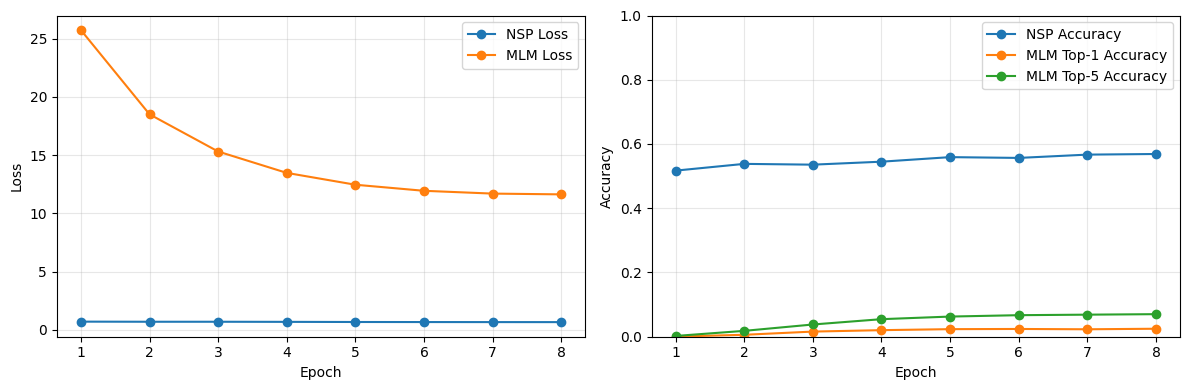

In [59]:
history_df = pd.DataFrame(history)
history_df.index = range(1, len(history_df) + 1)
history_df.index.name = "epoch"
display(history_df)

x = history_df.index.to_list()
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(x, history_df["nsp_loss"], marker="o", label="NSP Loss")
plt.plot(x, history_df["mlm_loss"], marker="o", label="MLM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(x)
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(x, history_df["nsp_acc"], marker="o", label="NSP Accuracy")
plt.plot(x, history_df["mlm_acc"], marker="o", label="MLM Top-1 Accuracy")
plt.plot(x, history_df["mlm_top5_acc"], marker="o", label="MLM Top-5 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(x)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


## 루브릭 정리

- SentencePiece tokenizer로 한국어 코퍼스를 토큰화하고, MLM/NSP pretraining instance를 생성했습니다.
- `mask_idx`, `mask_label`로 MLM 정답 위치와 정답 토큰을 저장했고, `segment`, `is_next`로 NSP 정보를 저장했습니다.
- mini BERT 모델을 구현하고 MLM loss와 NSP loss를 함께 계산하며 학습했습니다.
- 학습 history를 표와 그래프로 시각화하여 loss 변화를 확인했습니다.
